In [116]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import pandas as pd
import numpy as np
import json
import helper
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
import warnings

from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from itertools import product

from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import max_error



merged_weather_and_corn_production_data_dir = "./aggregated_dataset/merged_weather_and_corn_production_data.csv"
merged_weather_and_cotton_production_data_dir = "./aggregated_dataset/merged_weather_and_cotton_production_data.csv"
merged_weather_and_soybeans_production_data_dir = "./aggregated_dataset/merged_weather_and_soybeans_production_data.csv"
merged_weather_and_wheat_production_data_dir = "./aggregated_dataset/merged_weather_and_wheat_production_data.csv"

In [3]:
selected_states = {}
with open("selected_states.json") as file:
    selected_states = json.load(file)
    
print(selected_states)

{'TX': 'TEXAS', 'CA': 'CALIFORNIA', 'SD': 'SOUTH DAKOTA', 'ND': 'NORTH DAKOTA', 'AR': 'ARKANSAS', 'KS': 'KANSAS'}


In [4]:

soybeans_dataset = pd.read_csv(merged_weather_and_soybeans_production_data_dir)
cotton_dataset = pd.read_csv(merged_weather_and_cotton_production_data_dir)
wheat_dataset = pd.read_csv(merged_weather_and_wheat_production_data_dir)

In [38]:
corn_rf_selected_features_params = {
    'n_estimators': 100, 
    'max_depth': None, 
    'min_samples_split': 5, 
    'min_samples_leaf': 2, 
    'max_features': None
}

soybeans_hgb_complete_features_params = {
    'learning_rate': 0.01, 
    'max_iter': 1000, 
    'max_depth': 5, 
    'l2_regularization': 0.5, 
    'min_samples_leaf': 20
}

cotton_rf_selected_features_params = {
    'n_estimators': 100, 
    'max_depth': None, 
    'min_samples_split': 5, 
    'min_samples_leaf': 1, 
    'max_features': None
}

wheat_rf_complete_features_params = {
    'n_estimators': 100, 
    'max_depth': 10, 
    'min_samples_split': 5, 
    'min_samples_leaf': 1, 
    'max_features': None
}

# 1. Corn Final Prediction

In [ ]:
corn_target = 'PRODUCTION, MEASURED IN BU'

In [71]:
corn_dataset = pd.read_csv(merged_weather_and_corn_production_data_dir)
complete_corn_dataset = corn_dataset.drop(["Unnamed: 0", "State", "County", "FIPS Code"], axis=1)


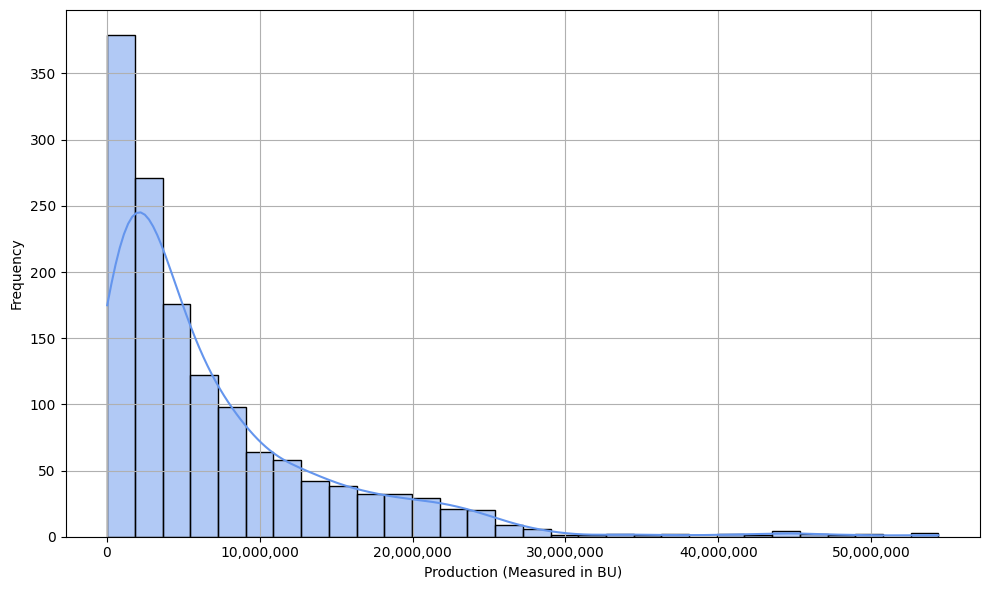

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Formatter function to convert large numbers to readable format
def format_large_tick(x, pos):
    return f'{int(x):,}'

plt.figure(figsize=(10, 6))
sns.histplot(
    data=selected_features_corn_dataset,
    x='PRODUCTION, MEASURED IN BU',
    bins=30,
    kde=True,
    color='cornflowerblue'
)

# plt.title('Distribution of Corn Production')
plt.xlabel('Production (Measured in BU)')
plt.ylabel('Frequency')
plt.grid(True)

# Apply custom formatter to x-axis
plt.gca().xaxis.set_major_formatter(FuncFormatter(format_large_tick))

plt.tight_layout()
plt.show()


In [73]:
train_set_corn, test_set_corn = helper.split_dataset_by_year(complete_corn_dataset, 2022)

In [74]:
corn_pred_results = helper.train_final_model_and_predict_log_transformed(
    train_set=train_set_corn,
    test_set=test_set_corn, 
    target_column=corn_target,
    model=RandomForestRegressor(random_state=42, **corn_rf_selected_features_params)
)


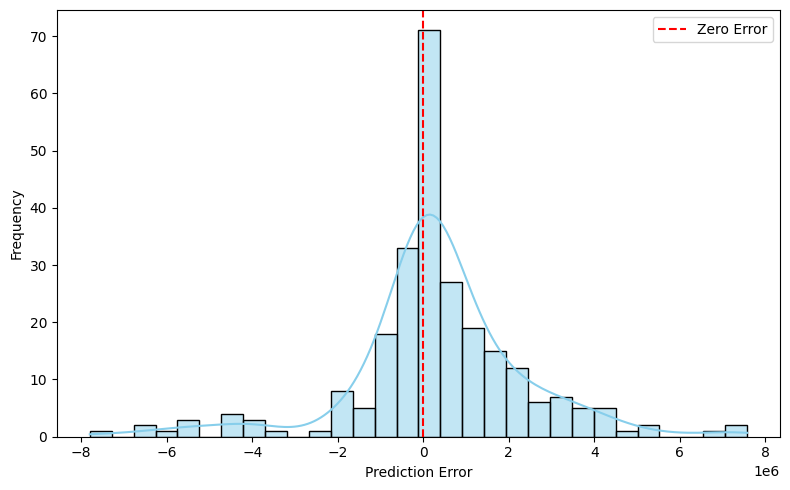

In [75]:
helper.plot_error_distribution(test_set_corn[corn_target], corn_pred_results['test_predictions'])

In [76]:
helper.print_metrics(corn_pred_results['test_metrics'], "Corn Final Prediction Eval Metrics")

Corn Final Prediction Eval Metrics
  R² Score       : 0.92
  MAE            : 1.36M
  RMSE           : 2.09M
  MAPE           : 43.20%
  Max Error      : 7.80M


# 2. Soybeans Final Prediction

In [77]:
soybeans_target = "PRODUCTION, MEASURED IN BU"

In [78]:
soybeans_dataset = pd.read_csv(merged_weather_and_soybeans_production_data_dir)
complete_soybeans_dataset = soybeans_dataset.drop(["Unnamed: 0", "State", "County", "FIPS Code"], axis=1)
complete_soybeans_dataset

,Avg Temperature (C),Max Temperature (C),Min Temperature (C),Heat_Stress_Day,Cold_Stress_Day,Precipitation (mm),Vapor Pressure Deficit (kPa),Drought_Stress_Day,Wet_Day,Heavy_Rain_Day,Solar Radiation (MJ m**-2 day**-1),Low_Light_Day,Relative Humidity (%),Wind Speed (m s**-1),Year,"PRODUCTION, MEASURED IN BU",harvested_area
0,17.778272,35.917027,-11.813784,5.567568,127.891892,1652.416135,0.696802,0.000000,104.648649,18.864865,126087.217712,5.918919,71.964857,5.487101,2017,10040000.0,186964.618250
1,18.603199,35.795500,-8.312000,3.700000,108.800000,1844.636750,0.683657,0.000000,113.000000,23.200000,122775.899299,11.200000,73.309178,5.077573,2017,3490000.0,61443.661972
2,18.669693,35.024000,-8.272000,1.200000,100.933333,1869.680867,0.641058,0.000000,112.333333,25.666667,127958.411779,9.200000,74.422411,5.543904,2017,8647000.0,168886.718750
3,16.135538,35.586250,-11.329375,3.375000,149.125000,1388.596562,0.616330,0.000000,104.312500,13.937500,130721.404219,7.687500,72.694829,4.815941,2017,6583000.0,120127.737226
4,16.813532,35.128667,-14.166000,2.666667,143.066667,1579.031467,0.613917,0.000000,103.266667,20.800000,127231.905283,10.933333,73.269534,2.827332,2017,745000.0,18908.629442
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1075,18.416672,41.462083,-13.213333,67.250000,131.916667,679.067958,1.068879,23.041667,50.250000,7.958333,148098.711053,18.625000,61.609943,3.771743,2022,63000.0,3750.000000
1076,18.263845,41.040800,-13.519200,64.800000,133.960000,685.627920,1.004137,15.480000,55.960000,8.240000,145956.933936,18.640000,63.513699,3.627239,2022,110000.0,9166.666667
1077,14.646052,42.690000,-19.465000,60.150000,184.750000,185.716650,1.222846,34.700000,30.400000,0.550000,165870.188381,12.100000,48.896740,4.936296,2022,139000.0,3492.462312
1078,21.463896,39.329394,-8.130303,66.939394,88.181818,520.929485,0.877018,0.000000,53.181818,4.878788,148370.152427,18.606061,71.104193,5.979935,2022,34500.0,2379.310345


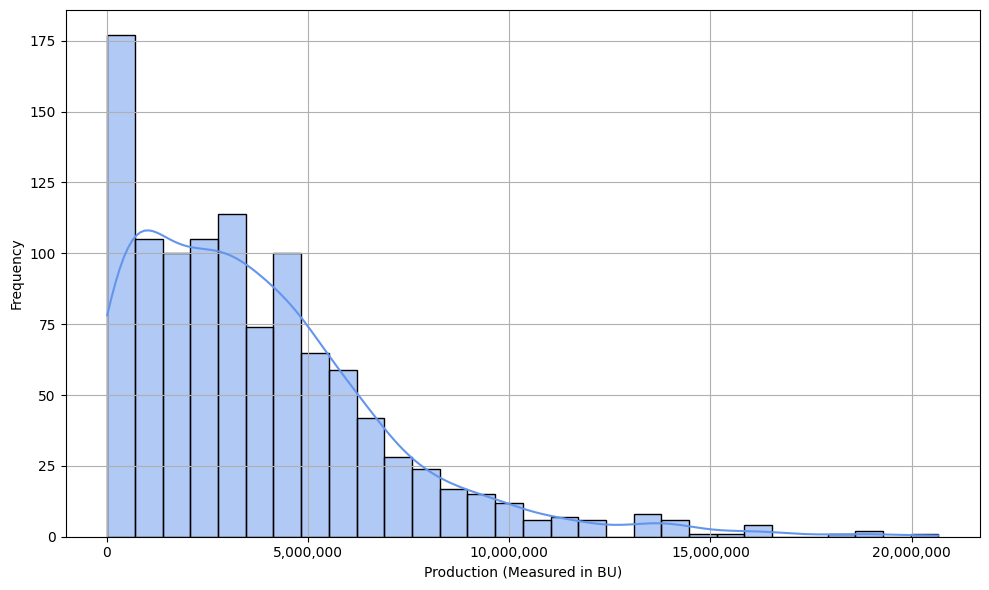

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Formatter function to convert large numbers to readable format
def format_large_tick(x, pos):
    return f'{int(x):,}'

plt.figure(figsize=(10, 6))
sns.histplot(
    data=complete_soybeans_dataset,
    x='PRODUCTION, MEASURED IN BU',
    bins=30,
    kde=True,
    color='cornflowerblue'
)

# plt.title('Distribution of Corn Production')
plt.xlabel('Production (Measured in BU)')
plt.ylabel('Frequency')
plt.grid(True)

# Apply custom formatter to x-axis
plt.gca().xaxis.set_major_formatter(FuncFormatter(format_large_tick))

plt.tight_layout()
plt.show()


In [80]:
train_set_soybeans, test_set_soybeans = helper.split_dataset_by_year(complete_soybeans_dataset, 2022)

In [81]:
soybeans_pred_results = helper.train_final_model_and_predict_log_transformed(
    train_set=train_set_soybeans,
    test_set=test_set_soybeans, 
    target_column=soybeans_target,
    model=HistGradientBoostingRegressor(random_state=42, **soybeans_hgb_complete_features_params)
)


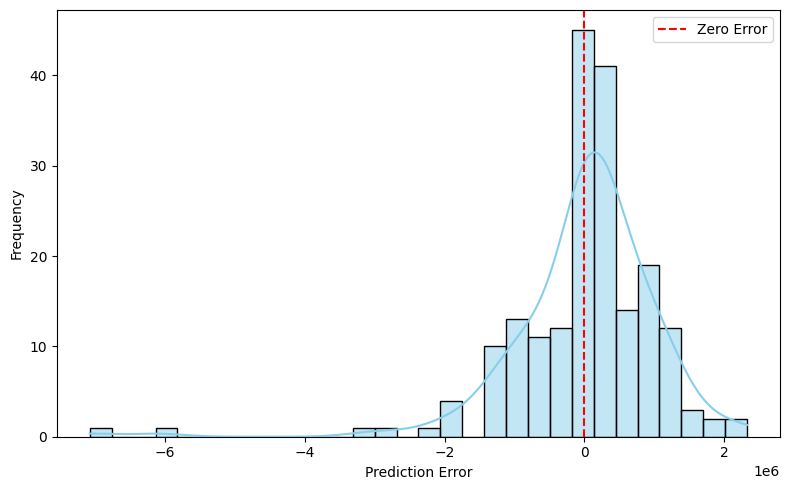

In [82]:
helper.plot_error_distribution(test_set_soybeans[soybeans_target], soybeans_pred_results['test_predictions'])

In [83]:
helper.print_metrics(soybeans_pred_results['test_metrics'], "Soybeans Final Prediction Eval Metrics")

Soybeans Final Prediction Eval Metrics
  R² Score       : 0.88
  MAE            : 686.76K
  RMSE           : 1.08M
  MAPE           : 35.84%
  Max Error      : 7.08M


# 3. Cotton Final Prediction

In [84]:
cotton_target = "PRODUCTION, MEASURED IN 480 LB BALES"

cotton_selected_columns = [
    'Avg Temperature (C)',
    'Min Temperature (C)',
    'Heat_Stress_Day',
    'Cold_Stress_Day',
    'Wind Speed (m s**-1)',
    cotton_target,
    'harvested_area',
    'Year'
]

In [85]:
merged_cotton_dataset = pd.read_csv(merged_weather_and_cotton_production_data_dir)

complete_cotton_dataset = merged_cotton_dataset.drop(["Unnamed: 0", "State", "County", "FIPS Code"], axis=1)
selected_features_cotton_dataset = complete_cotton_dataset[cotton_selected_columns]
selected_features_cotton_dataset

,Avg Temperature (C),Min Temperature (C),Heat_Stress_Day,Cold_Stress_Day,Wind Speed (m s**-1),"PRODUCTION, MEASURED IN 480 LB BALES",harvested_area,Year
0,18.603199,-8.312000,3.700000,108.800000,5.077573,55700.0,49.161518,2017
1,18.669693,-8.272000,1.200000,100.933333,5.543904,34400.0,34.572864,2017
2,16.135538,-11.329375,3.375000,149.125000,4.815941,85400.0,63.731343,2017
3,16.506291,-13.352500,2.312500,141.375000,5.196781,163000.0,138.723404,2017
4,17.549455,-13.142273,0.636364,126.045455,5.111983,46400.0,40.630473,2017
...,...,...,...,...,...,...,...,...
665,18.380986,-12.756923,97.730769,146.730769,4.350502,21300.0,24.796275,2022
666,22.700379,-8.792500,42.083333,59.166667,6.951762,101100.0,139.640884,2022
667,20.250513,-10.844286,78.023810,103.357143,3.714269,10500.0,24.193548,2022
668,16.195158,-15.552500,55.875000,170.812500,4.302007,22000.0,52.884615,2022


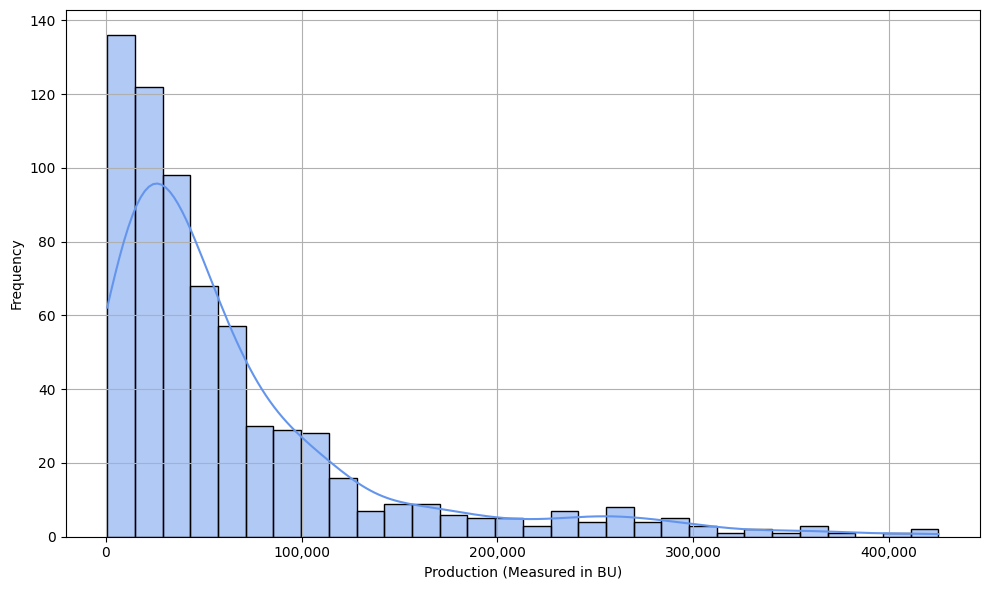

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Formatter function to convert large numbers to readable format
def format_large_tick(x, pos):
    return f'{int(x):,}'

plt.figure(figsize=(10, 6))
sns.histplot(
    data=selected_features_cotton_dataset,
    x=cotton_target,
    bins=30,
    kde=True,
    color='cornflowerblue'
)

# plt.title('Distribution of Corn Production')
plt.xlabel('Production (Measured in BU)')
plt.ylabel('Frequency')
plt.grid(True)

# Apply custom formatter to x-axis
plt.gca().xaxis.set_major_formatter(FuncFormatter(format_large_tick))

plt.tight_layout()
plt.show()


In [87]:
train_set_cotton, test_set_cotton = helper.split_dataset_by_year(selected_features_cotton_dataset, 2022)

In [88]:
cotton_pred_results = helper.train_final_model_and_predict(
    train_set=train_set_cotton,
    test_set=test_set_cotton, 
    target_column=cotton_target,
    model=RandomForestRegressor(random_state=42, **cotton_rf_selected_features_params)
)


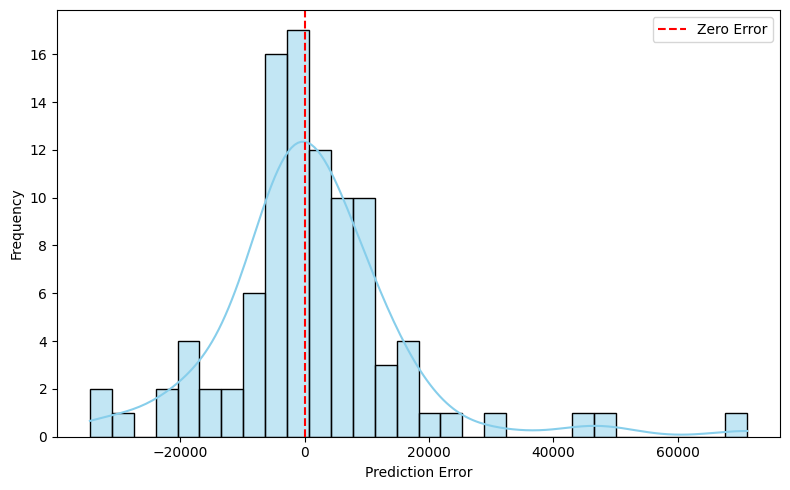

In [89]:
helper.plot_error_distribution(test_set_cotton[cotton_target], cotton_pred_results['test_predictions'])

In [90]:
helper.print_metrics(cotton_pred_results['test_metrics'], "Cotton Final Prediction Eval Metrics")

Cotton Final Prediction Eval Metrics
  R² Score       : 0.89
  MAE            : 9.50K
  RMSE           : 14.64K
  MAPE           : 33.77%
  Max Error      : 71.19K


# 4. Wheat Final Prediction

In [91]:
wheat_target = "PRODUCTION, MEASURED IN BU"

In [92]:
wheat_dataset = pd.read_csv(merged_weather_and_wheat_production_data_dir)
complete_wheat_dataset = wheat_dataset.drop(["Unnamed: 0", "State", "County", "FIPS Code"], axis=1)
complete_wheat_dataset

,Avg Temperature (C),Max Temperature (C),Min Temperature (C),Heat_Stress_Day,Cold_Stress_Day,Precipitation (mm),Vapor Pressure Deficit (kPa),Drought_Stress_Day,Wet_Day,Heavy_Rain_Day,Solar Radiation (MJ m**-2 day**-1),Low_Light_Day,Relative Humidity (%),Wind Speed (m s**-1),Year,"PRODUCTION, MEASURED IN BU",harvested_area
0,18.603199,35.795500,-8.312000,3.700000,108.800000,1844.636750,0.683657,0.000000,113.000000,23.200000,122775.899299,11.200000,73.309178,5.077573,2017,76000.0,1200.631912
1,17.073877,35.524000,-13.501000,3.500000,138.600000,1545.755900,0.672345,0.000000,106.700000,17.400000,128836.079107,8.900000,71.646164,5.383557,2017,282000.0,4298.780488
2,17.776995,35.603571,-11.829643,3.428571,129.285714,1674.127393,0.694004,0.000000,98.821429,20.535714,128384.228831,5.892857,71.776575,5.074015,2017,240000.0,5405.405405
3,17.374002,35.664286,-13.952857,5.142857,132.428571,1581.354643,0.662848,0.000000,105.428571,16.642857,132428.745516,6.642857,72.692975,5.409999,2017,225000.0,4697.286013
4,17.963515,34.832143,-12.094286,1.000000,125.571429,1779.666429,0.671998,0.000000,103.500000,19.785714,127787.722613,7.357143,72.480763,5.143745,2017,206000.0,4497.816594
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1193,20.250513,41.017857,-10.844286,78.023810,103.357143,553.008690,1.105926,10.095238,46.571429,6.523810,153875.616961,16.476190,63.261735,3.714269,2022,233000.0,6676.217765
1194,21.392574,41.521429,-7.938214,104.214286,95.928571,329.569571,1.156840,3.892857,37.928571,3.142857,154536.885121,15.178571,63.404912,4.083249,2022,5000.0,230.414747
1195,18.878895,43.502500,-12.648500,77.500000,130.000000,574.534350,1.242541,41.300000,43.050000,6.850000,155632.124477,15.000000,56.900205,3.706686,2022,44600.0,2207.920792
1196,16.195158,40.266875,-15.552500,55.875000,170.812500,188.818000,1.350214,54.375000,30.875000,0.437500,176941.193213,12.687500,46.753596,4.302007,2022,19800.0,1980.000000


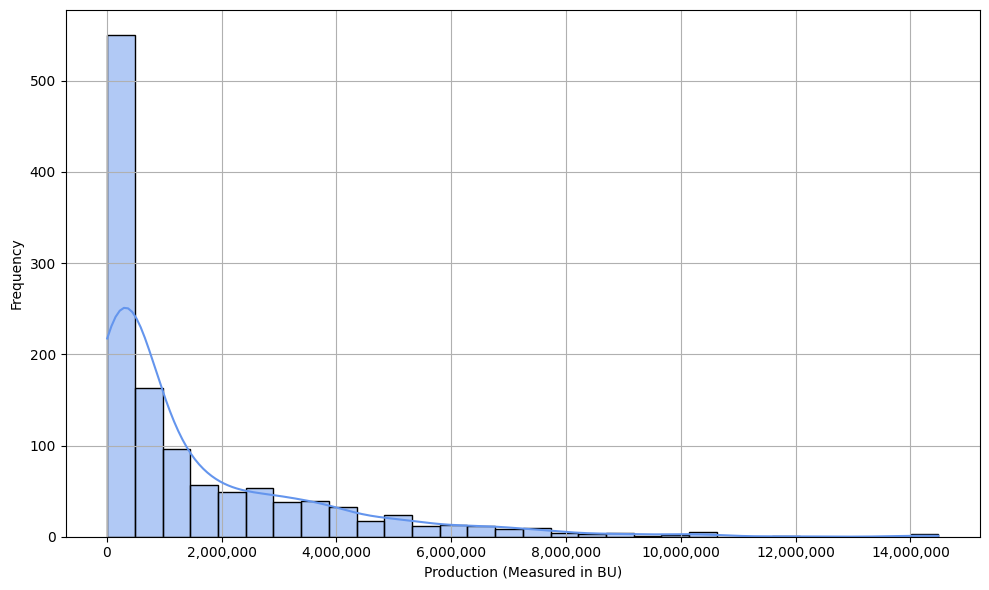

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Formatter function to convert large numbers to readable format
def format_large_tick(x, pos):
    return f'{int(x):,}'

plt.figure(figsize=(10, 6))
sns.histplot(
    data=complete_wheat_dataset,
    x=wheat_target,
    bins=30,
    kde=True,
    color='cornflowerblue'
)

# plt.title('Distribution of Corn Production')
plt.xlabel('Production (Measured in BU)')
plt.ylabel('Frequency')
plt.grid(True)

# Apply custom formatter to x-axis
plt.gca().xaxis.set_major_formatter(FuncFormatter(format_large_tick))

plt.tight_layout()
plt.show()


In [94]:
train_set_wheat, test_set_wheat = helper.split_dataset_by_year(complete_wheat_dataset, 2022)

In [95]:
wheat_pred_results = helper.train_final_model_and_predict(
    train_set=train_set_wheat,
    test_set=test_set_wheat, 
    target_column=wheat_target,
    model=RandomForestRegressor(random_state=42, **wheat_rf_complete_features_params)
)


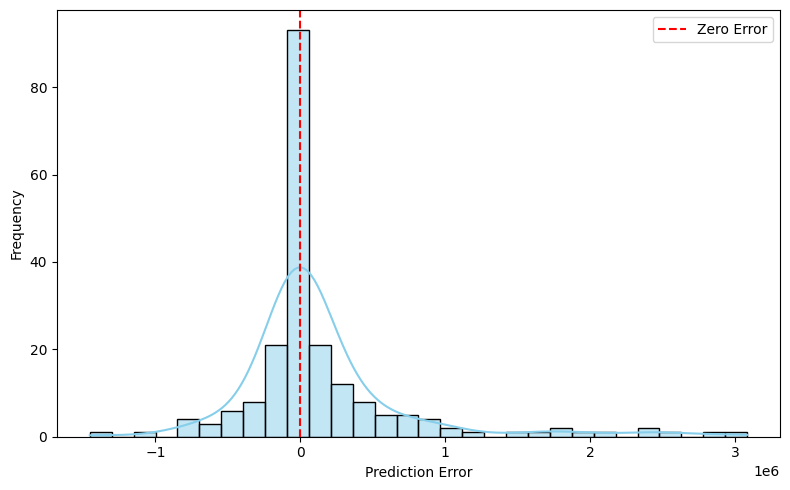

In [96]:
helper.plot_error_distribution(test_set_wheat[wheat_target], wheat_pred_results['test_predictions'])

In [63]:
helper.print_metrics(wheat_pred_results['test_metrics'], "Wheat Final Prediction Eval Metrics")

Wheat Final Prediction Eval Metrics
  R² Score       : 0.86
  MAE            : 318.77K
  RMSE           : 617.75K
  MAPE           : 35.24%
  Max Error      : 3.08M
